## Setup

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import heapq
from collections import deque
import numpy as np

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 7)
plt.rcParams['figure.dpi'] = 100

## Part 1: Building a Weighted Graph with Heuristic Values
<hr>

### The Ireland Map

In [2]:
# Build the Ireland map as a weighted graph
ireland = nx.Graph()

# Add edges with distances (km)
ireland.add_edge('Galway', 'Limerick', weight=105)
ireland.add_edge('Galway', 'Belfast', weight=306)
ireland.add_edge('Limerick', 'Belfast', weight=323)
ireland.add_edge('Limerick', 'Cork', weight=121)
ireland.add_edge('Cork', 'Dublin', weight=220)
ireland.add_edge('Cork', 'Waterford', weight=126)
ireland.add_edge('Waterford', 'Dublin', weight=158)
ireland.add_edge('Dublin', 'Belfast', weight=167)

# Heuristic: straight-line distance to Waterford (km)
heuristic = {
    'Galway': 200, 'Limerick': 170, 'Belfast': 270,
    'Cork': 120, 'Dublin': 130, 'Waterford': 0
}

# Store heuristic as node attribute
for city, h in heuristic.items():
    ireland.nodes[city]['h'] = h

print("Cities:", list(ireland.nodes()))
print("\nConnections and distances:")
for u, v, data in ireland.edges(data=True):
    print(f" {u} <-> {v}: {data['weight']} km")
print("\nHeuristic values (crow-flies distance to Waterford)")

for city, h in sorted(heuristic.items(), key=lambda x: x[1]):
    print(f"  {city}: h = {h} km")

Cities: ['Galway', 'Limerick', 'Belfast', 'Cork', 'Dublin', 'Waterford']

Connections and distances:
 Galway <-> Limerick: 105 km
 Galway <-> Belfast: 306 km
 Limerick <-> Belfast: 323 km
 Limerick <-> Cork: 121 km
 Belfast <-> Dublin: 167 km
 Cork <-> Dublin: 220 km
 Cork <-> Waterford: 126 km
 Dublin <-> Waterford: 158 km

Heuristic values (crow-flies distance to Waterford)
  Waterford: h = 0 km
  Cork: h = 120 km
  Dublin: h = 130 km
  Limerick: h = 170 km
  Galway: h = 200 km
  Belfast: h = 270 km


### Visualising the Ireland Map

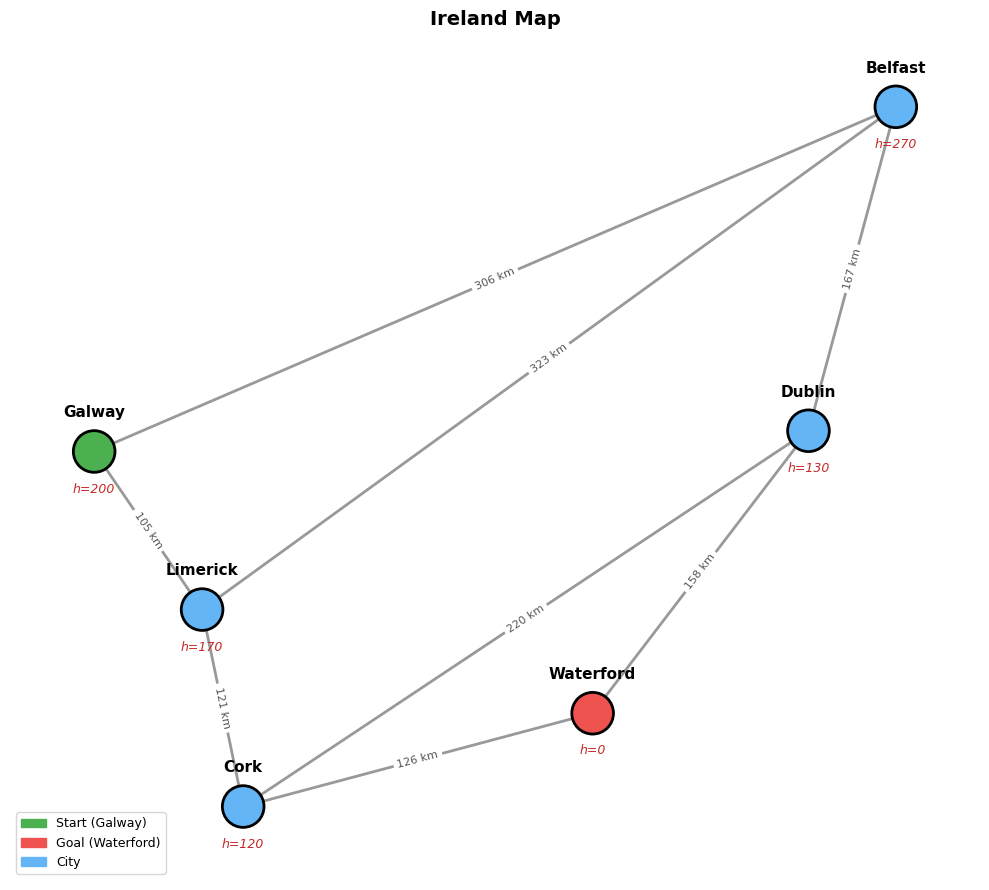

In [3]:
# Geographic-ish positions for Irish cities
ireland_pos = {
    'Galway': (-9.05, 53.27),
    'Limerick': (-8.63, 52.66),
    'Cork': (-8.47, 51.90),
    'Waterford': (-7.11, 52.26),
    'Dublin': (-6.27, 53.35),
    'Belfast': (-5.93, 54.60),
}

def draw_ireland(graph, pos, h, title='Ireland Map', highlight_path=None,
                 highlight_cost=None, extra_nodes=None, extra_h=None):
    """Draw the Ireland map with distances and heuristic values."""
    fig, ax = plt.subplots(figsize=(10, 9))

    all_h = dict(h)
    if extra_h:
        all_h.update(extra_h)

    # Node colours
    node_colors = []
    for n in graph.nodes():
        if n == 'Galway':
            node_colors.append('#4CAF50')
        elif n == 'Waterford':
            node_colors.append('#EF5350')
        else:
            node_colors.append('#64B5F6')
    
    # Draw edges with distance labels
    nx.draw_networkx_edges(graph, pos, ax=ax, edge_color='#999999', width=2)
    edge_labels = {(u, v): f"{d['weight']} km" for u,v, d in graph.edges(data=True)}
    nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, ax=ax,
                                font_size=8, font_color='#555555')
    
    # Highlight path if provided
    if highlight_path:
        path_edges = list(zip(highlight_path[:-1], highlight_path[1:]))
        nx.draw_networkx_edges(graph, pos, edgelist=path_edges,
                               edge_color='#E91E63', width=2, ax=ax)
    # Draw nodes
    nx.draw_networkx_nodes(graph, pos, ax=ax, node_color=node_colors,
                           node_size=900, edgecolors='black', linewidths=2)
    
    # Labels: city name and h(n) value
    for node, (x, y) in pos.items():
        ax.text(x, y + 0.12, node, ha='center', va='bottom',
                fontsize=11, fontweight='bold')
        if node in all_h:
            ax.text(x, y - 0.12, f'h={all_h[node]}', ha='center', va='top',
                    fontsize=9, color='#C62828', fontstyle='italic')
            
    # Legend
    legend_items = [
        mpatches.Patch(color='#4CAF50', label='Start (Galway)'),
        mpatches.Patch(color='#EF5350', label='Goal (Waterford)'),
        mpatches.Patch(color='#64B5F6', label='City'),
    ]
    if highlight_path:
        cost_str = f' (cost: {highlight_cost} km)' if highlight_cost else ''
        legend_items.append(mpatches.Patch(color='#E91E63',
                            label=f'Path: {" → ".join(highlight_path)}{cost_str}'))
    ax.legend(handles=legend_items, loc='lower left', fontsize=9)

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

draw_ireland(ireland, ireland_pos, heuristic)    
    

### Admissibility and Consistency

In [15]:
# Check admissibility: h(n) <= actual shortest distance to Waterford
print("Admissibility Check")
print("=" * 60)
shortest_to_goal = nx.single_source_dijkstra_path_length(ireland, 'Waterford')

for city in sorted(ireland.nodes()):
    actual = shortest_to_goal[city]
    h = heuristic[city]
    admissible = h <= actual
    print(f" {city:>10}: h={h:>3}, actual shortest={actual:>3}, "
          f"h <= actual? {admissible} {'✓' if admissible else '✗ NOT ADMISSIBLE'}")
    
# Check consistency: h(n) <= c(n,n') + h(n') for all edges
print(f"\nConsistency Check (Triangle Inequality)")
print("=" * 60)
all_consistent = True
for u, v, data in ireland.edges(data=True):
    c = data['weight']
    
    for n, np_ in [(u, v), (v, u)]:
        satisfied = heuristic[n] <= c + heuristic[np_]
        if not satisfied:
            all_consistent = False
        print(f" h({n})={heuristic[n]} <= c({n},{np_})={c} + h({np_})={heuristic[np_]} "
              f"= {c + heuristic[np_]}? {satisfied} {'✓' if satisfied else '✗'}")

print(f"\nHeuristic is {'consistent (and therefore admissible)' if all_consistent else 'NOT consistent'}.")

Admissibility Check
    Belfast: h=270, actual shortest=325, h <= actual? True ✓
       Cork: h=120, actual shortest=126, h <= actual? True ✓
     Dublin: h=130, actual shortest=158, h <= actual? True ✓
     Galway: h=200, actual shortest=352, h <= actual? True ✓
   Limerick: h=170, actual shortest=247, h <= actual? True ✓
  Waterford: h=  0, actual shortest=  0, h <= actual? True ✓

Consistency Check (Triangle Inequality)
 h(Galway)=200 <= c(Galway,Limerick)=105 + h(Limerick)=170 = 275? True ✓
 h(Limerick)=170 <= c(Limerick,Galway)=105 + h(Galway)=200 = 305? True ✓
 h(Galway)=200 <= c(Galway,Belfast)=306 + h(Belfast)=270 = 576? True ✓
 h(Belfast)=270 <= c(Belfast,Galway)=306 + h(Galway)=200 = 506? True ✓
 h(Limerick)=170 <= c(Limerick,Belfast)=323 + h(Belfast)=270 = 593? True ✓
 h(Belfast)=270 <= c(Belfast,Limerick)=323 + h(Limerick)=170 = 493? True ✓
 h(Limerick)=170 <= c(Limerick,Cork)=121 + h(Cork)=120 = 241? True ✓
 h(Cork)=120 <= c(Cork,Limerick)=121 + h(Limerick)=170 = 291? True

## Part 2: Hill Climbing (Steepest Ascent)
<hr>

### Hill Climbing Implementation

In [25]:
def hill_climbing(graph, h, start, goal):
    """
    Steepest-ascent hill climbing.

    At each step, selects the unvisited neighbour with the lowest h(n).
    Makes irrevocable choices — no backtracking.
    
    Returns:
        path: List of nodes from start to goal
        total_cost: Total distance travelled
        found: Whether the goal was reached
        trace: Step-by-step trace for analysis
    """
    current = start
    path = [start]
    visited = {start}
    total_cost = 0
    trace = []

    while current != goal:
        neighbors = []
        for neighbor in graph.neighbors(current):
            if neighbor not in visited:
                dist = graph[current][neighbor]['weight']
                neighbors.append((h[neighbor], neighbor, dist))

        if not neighbors:
            trace.append({'node': current, 'neighbors': [], 'choice': 'STUCK'})
            return path, total_cost, False, trace
        
        # Sort by heuristic value (ascending)
        neighbors.sort(key=lambda x: x[0])

        trace.append({
            'node': current,
            'neighbors': [(n, hv, d) for hv, n, d in neighbors],
            'choice': neighbors[0][1]
        })

        # Choose the best (lowest h) neighbor - irrevocable
        _, best_node, dist = neighbors[0]
        visited.add(best_node)
        path.append(best_node)
        total_cost += dist
        current = best_node
    
    trace.append({'node': goal, 'neighbors': [], 'choice': 'GOAL'})
    return path, total_cost, True, trace

### Hill Climbing on the Base Map

Hill Climbing Trace:
Step           At Neighbours (name, h, dist) Choice
---------------------------------------------------------------------------
   1       Galway Limerick(h=170,d=105), Belfast(h=270,d=306) Limerick
   2     Limerick Cork(h=120,d=121), Belfast(h=270,d=323)  Cork
   3         Cork Waterford(h=0,d=126), Dublin(h=130,d=220) Waterford
   4    Waterford -                                        GOAL

Path: Galway → Limerick → Cork → Waterford
Total distance: 352 km


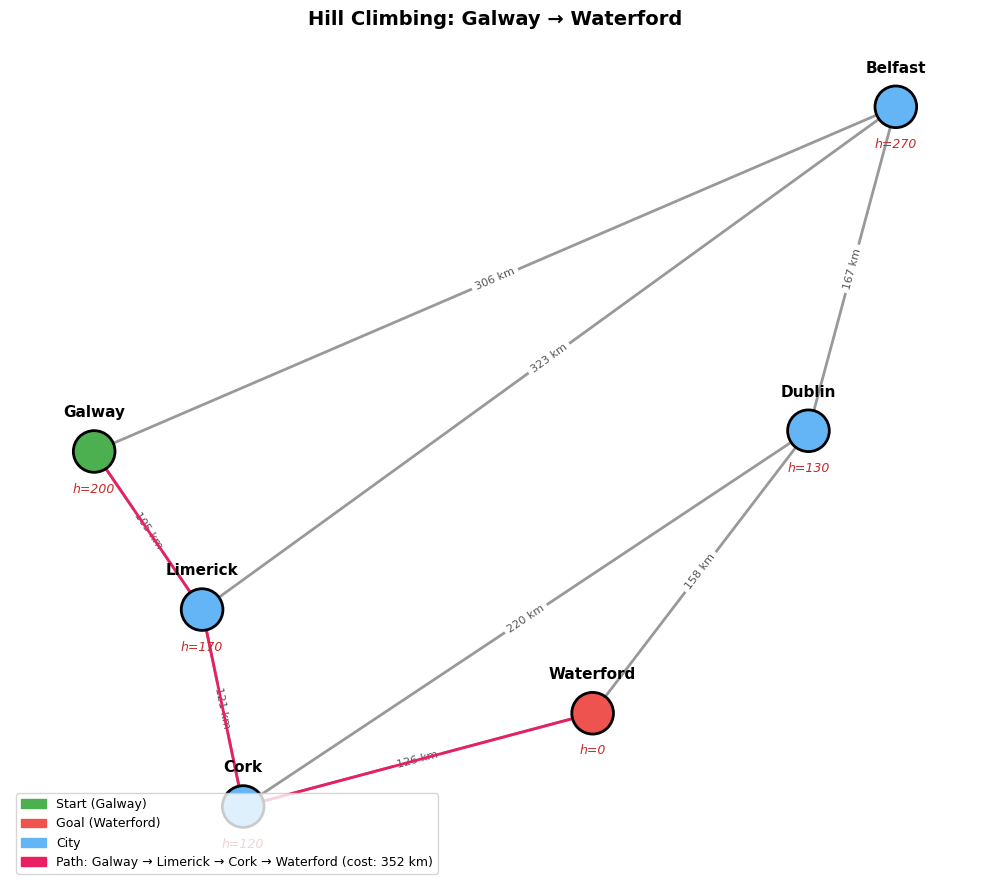

In [26]:
hc_path, hc_cost, hc_found, hc_trace = hill_climbing(ireland, heuristic, 'Galway', 'Waterford')

print("Hill Climbing Trace:")
print(f"{'Step':>4} {'At':>12} {'Neighbours (name, h, dist)':} {'Choice':}")
print("-" * 75)
for i, step in enumerate(hc_trace):
    nbrs = ', '.join(f"{n}(h={h},d={d})" for n, h, d in step['neighbors']) if step['neighbors'] else '-'
    print(f"{i+1:>4} {step['node']:>12} {nbrs:<40} {step['choice']}")

print(f"\nPath: {' → '.join(hc_path)}")
print(f"Total distance: {hc_cost} km")

draw_ireland(ireland, ireland_pos, heuristic,
            title='Hill Climbing: Galway → Waterford',
            highlight_path=hc_path, highlight_cost=hc_cost)

### Foothills - Adding Athlone

Hill Climbing with Athlone (foothill):
Step           At Neighbours (name, h, dist) Choice
---------------------------------------------------------------------------
   1       Galway Athlone(h=90,d=80), Limerick(h=170,d=105), Belfast(h=270,d=306) Athlone
   2      Athlone Belfast(h=270,d=300)                     Belfast
   3      Belfast Dublin(h=130,d=167), Limerick(h=170,d=323) Dublin
   4       Dublin Waterford(h=0,d=158), Cork(h=120,d=220)  Waterford
   5    Waterford -                                        GOAL

Path: Galway → Athlone → Belfast → Dublin → Waterford
Total distance: 705 km

Optimal path was: Galway → Limerick → Cork → Waterford = 352 km
Hill climbing was sidetracked: cost 705 km (353 km extra!)


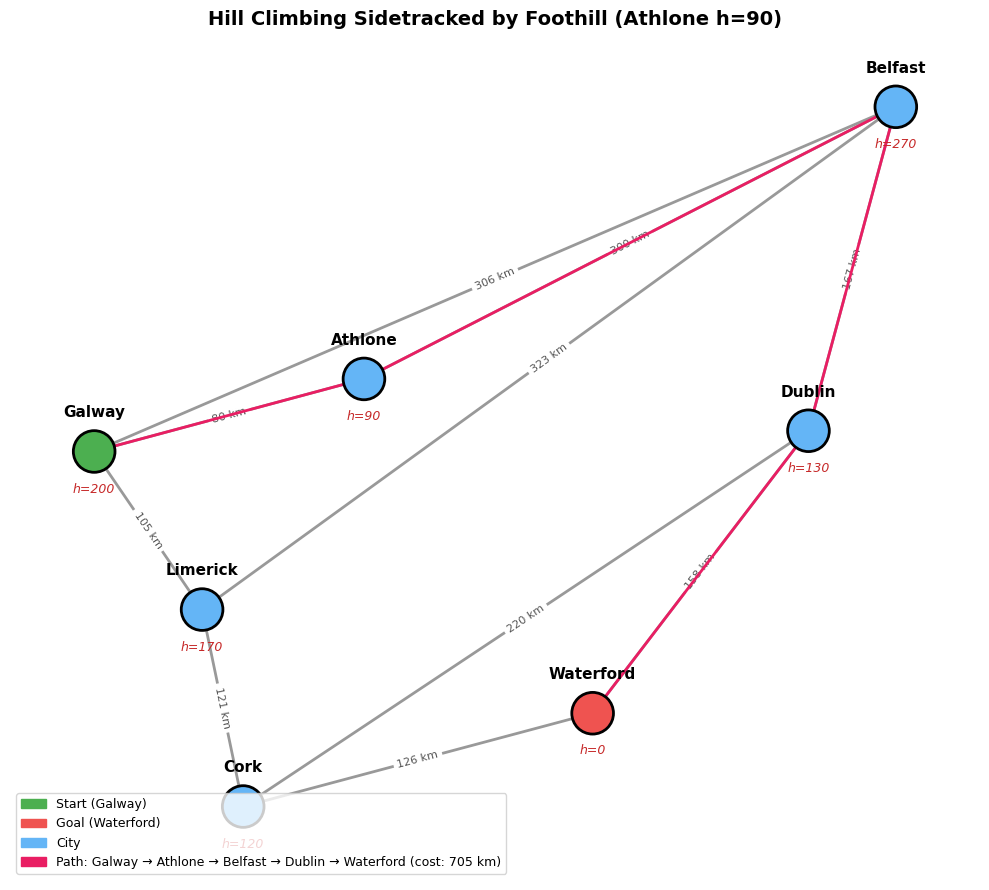

In [29]:
# Add Athlone to create a foothill
ireland_fh = ireland.copy()
ireland_fh.add_edge('Galway', 'Athlone', weight=80)
ireland_fh.add_edge('Athlone', 'Belfast', weight=300)

h_fh = dict(heuristic)
h_fh['Athlone'] = 90  # Deceptively low heuristic

# Update positions
pos_fh = dict(ireland_pos)
pos_fh['Athlone'] = (-8.0, 53.55)

hc_fh_path, hc_fh_cost, hc_fh_found, hc_fh_trace = hill_climbing(ireland_fh, h_fh, 'Galway', 'Waterford')

print("Hill Climbing with Athlone (foothill):")
print(f"{'Step':>4} {'At':>12} {'Neighbours (name, h, dist)':} {'Choice':}")
print("-" * 75)
for i, step in enumerate(hc_fh_trace):
    nbrs = ', '.join(f"{n}(h={h},d={d})" for n, h, d in step['neighbors']) if step['neighbors'] else '-'
    print(f"{i+1:>4} {step['node']:>12} {nbrs:<40} {step['choice']}")

print(f"\nPath: {' → '.join(hc_fh_path)}")
print(f"Total distance: {hc_fh_cost} km")
print(f"\nOptimal path was: Galway → Limerick → Cork → Waterford = 352 km")
print(f"Hill climbing was sidetracked: cost {hc_fh_cost} km ({hc_fh_cost - 352} km extra!)")

draw_ireland(ireland_fh, pos_fh, heuristic, extra_h={'Athlone': 90},
             title=f"Hill Climbing Sidetracked by Foothill (Athlone h=90)",
             highlight_path=hc_fh_path, highlight_cost=hc_fh_cost)

### Plateaux: Adding Nenagh and Adjusting Athlone

Hill Climbing with Plateaux:
Step           At Neighbours (name, h, dist) Choice
--------------------------------------------------------------------------------
   1       Galway Limerick(h=170,d=105), Athlone(h=170,d=80), Belfast(h=270,d=306) ** TIE ** Limerick
   2     Limerick Cork(h=120,d=121), Nenagh(h=120,d=40), Belfast(h=270,d=323) ** TIE ** Cork
   3         Cork Waterford(h=0,d=126), Dublin(h=130,d=220)               Waterford
   4    Waterford -                                                       GOAL

Path: Galway → Limerick → Cork → Waterford
Total distance: 352 km
Optimal path: Galway → Limerick → Cork → Waterford = 352 km
Penalty: 0 km extra


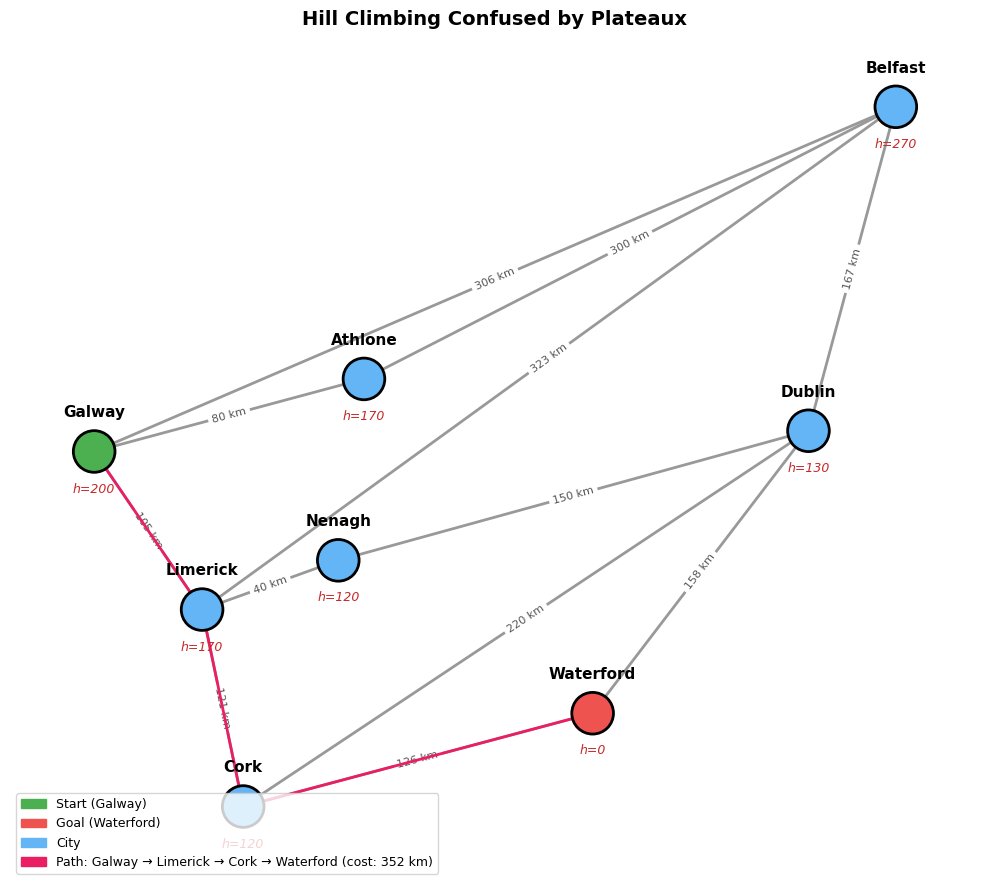

In [30]:
# Build the plateau map
ireland_pl = ireland_fh.copy()

# Adjust Athlone heuristic to match Limerick (plateau)
h_pl = dict(heuristic)
h_pl['Athlone'] = 170  # Same as Limerick

# Add Nenagh
ireland_pl.add_edge('Limerick', 'Nenagh', weight=40)
ireland_pl.add_edge('Nenagh', 'Dublin', weight=150)

h_pl['Nenagh'] = 120

pos_pl = dict(ireland_pos)
pos_pl['Athlone'] = (-8.0, 53.55)
pos_pl['Nenagh'] = (-8.1, 52.85)

hc_pl_path, hc_pl_cost, hc_pl_found, hc_pl_trace = hill_climbing(ireland_pl, h_pl, 'Galway', 'Waterford')

print("Hill Climbing with Plateaux:")
print(f"{'Step':>4} {'At':>12} {'Neighbours (name, h, dist)':} {'Choice':}")
print("-" * 80)
for i, step in enumerate(hc_pl_trace):
    nbrs = ', '.join(f"{n}(h={h},d={d})" for n, h, d in step['neighbors']) if step['neighbors'] else '-'
    # Highlight ties
    if step['neighbors'] and len(step['neighbors']) > 1:
        h_values = [h for n, h, d in step['neighbors']]
        if h_values[0] == h_values[1]:
            nbrs += ' ** TIE **'
    print(f"{i+1:>4} {step['node']:>12} {nbrs:<55} {step['choice']}")

print(f"\nPath: {' → '.join(hc_pl_path)}")
print(f"Total distance: {hc_pl_cost} km")
print(f"Optimal path: Galway → Limerick → Cork → Waterford = 352 km")
print(f"Penalty: {hc_pl_cost - 352} km extra")

draw_ireland(ireland_pl, pos_pl, heuristic,
            extra_h={'Athlone': 170, 'Nenagh': 120},
            title=f'Hill Climbing Confused by Plateaux',
            highlight_path=hc_pl_path, highlight_cost=hc_pl_cost)

## Part 3: Greedy Best-First Search
<hr>

### Greedy Best-First Search Implementation

In [31]:
def greedy_best_first(graph, h, start, goal):
    """
    Greedy Best-First Search using a priority queue sorted by h(n).
    
    Returns:
        path: Path from start to goal
        total_cost: Actual distance of the path
        expanded: Number of nodes expanded
        trace: Step-by-step trace
    """
    visited = set()
    # Priority queue: (h(n), node, path, cost)
    pq = [(h[start], start, [start], 0)]
    expanded = 0
    trace = []

    while pq:
        h_val, node, path, cost = heapq.heappop(pq)

        if node in visited:
            continue
        visited.add(node)
        expanded += 1

        # Record trace
        open_nodes = [(hv, n) for hv, n, _, _ in pq if n not in visited]
        trace.append({
            'visiting': node, 'h': h_val, 'cost_so_far': cost,
            'open': sorted(set(open_nodes)),
            'closed': sorted(visited)
        })

        if node == goal:
            return path, cost, expanded, trace
        
        for neighbor in graph.neighbors(node):
            if neighbor not in visited:
                dist = graph[node][neighbor]['weight']
                heapq.heappush(pq, (h[neighbor], neighbor,
                               path + [neighbor], cost + dist))
    
    return None, 0, expanded, trace

In [32]:
# Implement the Greedy Best First Search on the orignal map
gbf_path, gbf_cost, gbf_exp, gbf_trace = greedy_best_first(ireland, heuristic, 'Galway', 'Waterford')

print("Greedy Best-First Search Trace:")
print(f"{'Step':>4} {'Visiting':>12} {'h(n)':>5} {'Cost':>6} {'Open Queue':}")
print("-" * 70)
for i, step in enumerate(gbf_trace):
    open_str = ', '.join(f"{n}(h={h})" for h, n in step['open']) if step['open'] else 'empty'
    print(f"{i+1:>4} {step['visiting']:>12} {step['h']:>5} {step['cost_so_far']:>6} {open_str}")
    
print(f"\nPath: {' → '.join(gbf_path)}, cost = {gbf_cost} km, nodes expanded = {gbf_exp}")

Greedy Best-First Search Trace:
Step     Visiting  h(n)   Cost Open Queue
----------------------------------------------------------------------
   1       Galway   200      0 empty
   2     Limerick   170    105 Belfast(h=270)
   3         Cork   120    226 Belfast(h=270)
   4    Waterford     0    352 Dublin(h=130), Belfast(h=270)

Path: Galway → Limerick → Cork → Waterford, cost = 352 km, nodes expanded = 4


## Part 4: Beam Search
<hr>

### Beam Search Implementation

In [33]:
def beam_search(graph, h, start, goal, beam_width=2):
    """
    Beam Search: BFS-style level expansion with a beam width limit.

    At each level, keeps only the beam_width best nodes (lowest h)

    Returns:
        path:     Path from start to goal
        cost:     Total path cost
        expanded: Number of nodes expanded
        trace:    Level-by-level trace
    """
    # Each entry: (h, node, path, cost)
    current_level = [(h[start], start, [start], 0)]
    visited = {start}
    expanded = 0
    trace = []

    while current_level:
        trace.append({
            'level_nodes': [(n, hv) for hv, n, _, _ in current_level]
        })

        next_level = []
        for h_val, node, path, cost in current_level:
            expanded += 1

            if node == goal:
                return path, cost, expanded, trace
            
            for neighbor in graph.neighbors(node):
                if neighbor not in visited:
                    dist = graph[node][neighbor]['weight']
                    next_level.append((h[neighbor], neighbor,
                                       path + [neighbor], cost + dist))
        
        next_level.sort(key=lambda x: x[0])

        # Keep only beam-width best candidates
        current_level = []
        for item in next_level[:beam_width]:
            _, node, _, _ = item
            if node not in visited:
                visited.add(node)
                current_level.append(item)
    
    return None, 0, expanded, trace

beam_path, beam_cost, beam_exp, beam_trace = beam_search(ireland, heuristic, 'Galway', 'Waterford')

# Beam search with width 2
print(f"Beam Search (w=2): {' → '.join(beam_path)}, cost = {beam_cost} km, "
      f"expanded = {beam_exp}")

print("\nLevel-by-level:")
for i, level in enumerate(beam_trace):
    nodes_str = ', '.join(f"{n}(h={h})" for n, h in level['level_nodes'])
    print(f" Level {i}: {nodes_str}")

# Compare with width 1 and width 3
for w in [1, 3]:
    bp, bc, be, _ = beam_search(
        ireland, heuristic, 'Galway', 'Waterford', beam_width=w)
    if bp:
        print(f"\nBeam Search (w={w}): {' → '.join(bp)}, cost = {bc} km, expanded = {be}")
    else:
        print(f"\nBeam Search (w={w}): FAILED to find a path")

Beam Search (w=2): Galway → Limerick → Cork → Waterford, cost = 352 km, expanded = 6

Level-by-level:
 Level 0: Galway(h=200)
 Level 1: Limerick(h=170), Belfast(h=270)
 Level 2: Cork(h=120), Dublin(h=130)
 Level 3: Waterford(h=0)

Beam Search (w=1): Galway → Limerick → Cork → Waterford, cost = 352 km, expanded = 4

Beam Search (w=3): Galway → Limerick → Cork → Waterford, cost = 352 km, expanded = 6
